# Inicializando las librerias que se van a ocupar

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report

In [99]:
base = pd.read_csv('/content/datos_tratados.csv')
base.shape

(7043, 21)

# Conociendo los datos

In [100]:
base.sample(5)

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
1087,1,Male,0,0,0,1,1,Yes,DSL,No,...,No,Yes,No,No,Month-to-month,0,Mailed check,60.10,60.10,2.003333
2428,1,Female,0,1,0,16,1,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,1,Electronic check,100.00,1534.75,3.333333
575,1,Male,0,0,0,53,1,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,0,Bank transfer (automatic),85.45,4517.25,2.848333
3891,0,Female,0,1,1,52,1,Yes,Fiber optic,No,...,Yes,No,Yes,No,One year,1,Credit card (automatic),95.70,4976.15,3.190000
3028,0,Male,0,0,0,20,1,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,1,Bank transfer (automatic),108.20,2203.70,3.606667


In [101]:
X = base.drop('Churn',axis=1)
Y = base['Churn']
print(X.shape)
print(Y.shape)

(7043, 20)
(7043,)


In [103]:
columnas = X.columns
columnas

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Cuentas_diarias'],
      dtype='object')

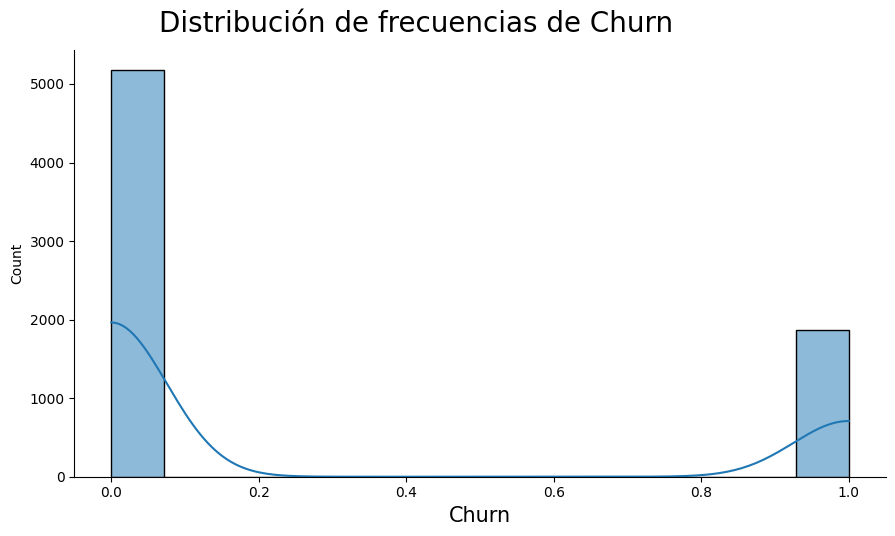

In [102]:
ax = sns.displot(base['Churn'], kde = True)
ax.figure.set_size_inches(10,5)
ax.fig.suptitle('Distribución de frecuencias de Churn', fontsize=20, y=1.05)
ax.set_xlabels("Churn", fontsize=15)
ax;

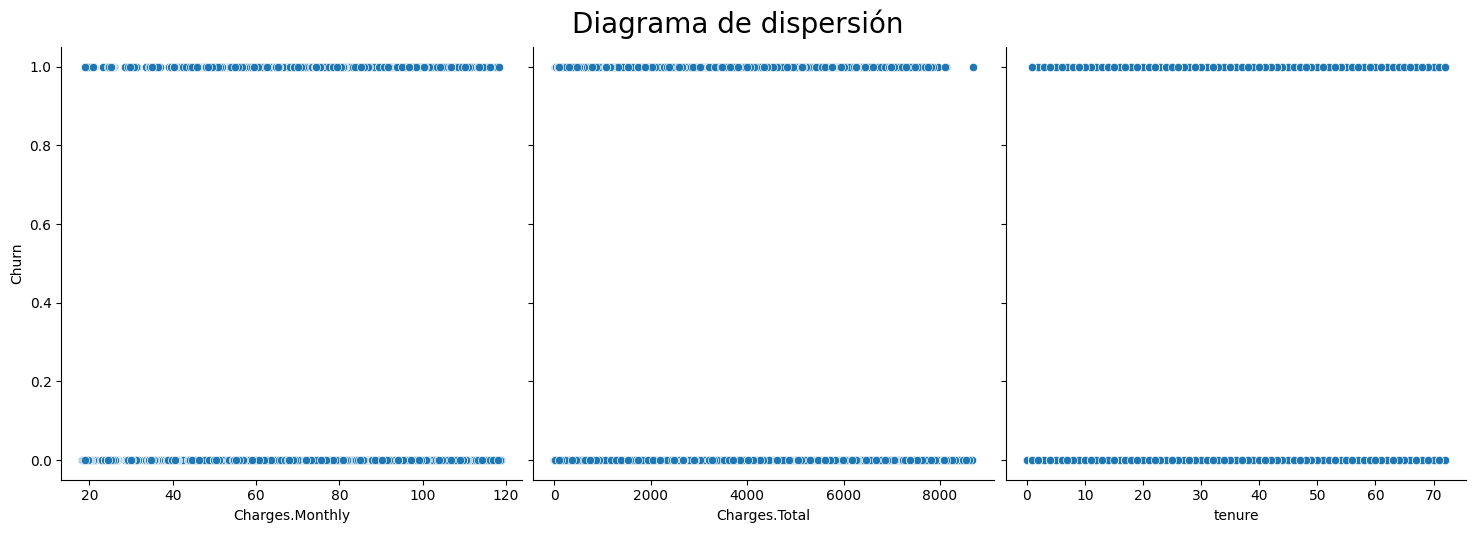

In [104]:
ax = sns.pairplot(base, y_vars='Churn', x_vars=[ 'Charges.Monthly', 'Charges.Total', 'tenure'], height=5)
ax.fig.suptitle('Diagrama de dispersión', fontsize=20, y=1.05)
ax;

# Preparar el modelo de predicción

In [105]:
one_hot = make_column_transformer(
          (OneHotEncoder(drop='if_binary'), ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']),
          remainder = 'passthrough',
          sparse_threshold=0,
          force_int_remainder_cols=False
          )


In [106]:
X = one_hot.fit_transform(X)

In [107]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__gender_Male', 'onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__OnlineSecurity_No',
       'onehotencoder__OnlineSecurity_No internet service',
       'onehotencoder__OnlineSecurity_Yes',
       'onehotencoder__OnlineBackup_No',
       'onehotencoder__OnlineBackup_No internet service',
       'onehotencoder__OnlineBackup_Yes',
       'onehotencoder__DeviceProtection_No',
       'onehotencoder__DeviceProtection_No internet service',
       'onehotencoder__DeviceProtection_Yes',
       'onehotencoder__TechSupport_No',
       'onehotencoder__TechSupport_No internet service',
       'onehotencoder__TechSupport_Yes', 'onehotencoder__StreamingTV_No',
       'onehotencoder__StreamingTV_No internet service',
       'onehotenco

In [108]:
X

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        6.56000000e+01, 5.93300000e+02, 2.18666667e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.99000000e+01, 5.42400000e+02, 1.99666667e+00],
       [1.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        7.39000000e+01, 2.80850000e+02, 2.46333333e+00],
       ...,
       [1.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        5.03000000e+01, 9.27500000e+01, 1.67666667e+00],
       [1.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        6.78500000e+01, 4.62765000e+03, 2.26166667e+00],
       [1.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        5.90000000e+01, 3.70760000e+03, 1.96666667e+00]])

In [109]:
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)
Y

array([0, 0, 1, ..., 0, 0, 0])

## Proporción de clientes activos vs clientes cancelados

### Se observa que existe una desproporción entre los clientes activos vs clientes cancelados, por lo que se sugiere un undersampling

In [110]:
Participación = base.groupby(['Churn'])['Churn'].count().reset_index(name="Conteo")
Participación['Porcentaje'] = round(Participación['Conteo'] / Participación['Conteo'].sum() * 100, 2)
Participación

,Churn,Conteo,Porcentaje
0,0,5174,73.46
1,1,1869,26.54


In [111]:
X, X_test, Y, Y_test = train_test_split(X, Y, test_size=0.20, stratify=Y, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.20, stratify=Y, random_state=5)

# Generando modelo Undersample

In [112]:
#Pipeline Undersampling

modelo_undersampling = DecisionTreeClassifier(max_depth=5)
pipeline = Pipeline([('undersample', NearMiss(version = 3)), ('arbol',modelo_undersampling)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados_undersampling = cross_validate(pipeline, X, Y, cv=skf, scoring='recall')
print(f'El test_score promedio es de : {round(cv_resultados_undersampling['test_score'].mean(),4)}')
print(pd.DataFrame(cv_resultados_undersampling))

El test_score promedio es de : 0.7104
   fit_time  score_time  test_score
0  0.103483    0.007013    0.678930
1  0.103071    0.008426    0.665552
2  0.104940    0.005921    0.712375
3  0.101009    0.007095    0.752508
4  0.110626    0.006053    0.742475


              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1035
           1       0.51      0.68      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.74      0.75      1409



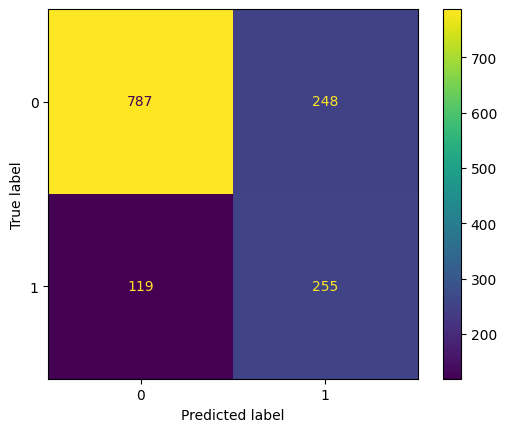

In [113]:
undersample = NearMiss(version = 3)
X_balanceada, Y_balanceada = undersample.fit_resample(X, Y)

modelo_undersampling = DecisionTreeClassifier(max_depth=5)
modelo_undersampling.fit(X_balanceada, Y_balanceada)
Y_previsto_undersampling = modelo_undersampling.predict(X_test)
print(classification_report(Y_test, Y_previsto_undersampling))
ConfusionMatrixDisplay.from_predictions(Y_test,Y_previsto_undersampling);

# Creando modelo Oversample

In [114]:
#Pipeline Oversampling

modelo_oversampling = DecisionTreeClassifier(max_depth=5)
pipeline = Pipeline([('oversample', SMOTE()), ('arbol',modelo_oversampling)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados_oversampling = cross_validate(pipeline, X, Y, cv=skf, scoring='recall')
print(f'El test_score promedio es de : {round(cv_resultados_oversampling['test_score'].mean(),4)}')
print(pd.DataFrame(cv_resultados_oversampling))

El test_score promedio es de : 0.5826
   fit_time  score_time  test_score
0  0.069144    0.003970    0.568562
1  0.063105    0.003891    0.605351
2  0.062771    0.004440    0.578595
3  0.063347    0.004397    0.581940
4  0.066541    0.003553    0.578595


              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.58      0.56      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



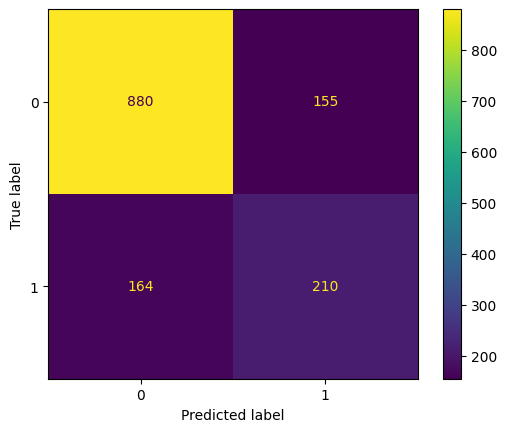

In [117]:
oversampling =  SMOTE()
X_balanceada, Y_balanceada = oversampling.fit_resample(X, Y)

modelo_oversampling = DecisionTreeClassifier(max_depth=5)
modelo_oversampling.fit(X_balanceada, Y_balanceada)
Y_previsto_oversampling = modelo_oversampling.predict(X_test)
print(classification_report(Y_test, Y_previsto_oversampling))
ConfusionMatrixDisplay.from_predictions(Y_test,Y_previsto_oversampling);

# Conclusiones

Con base al análisis exploratorio de la información, se identificó que existe un desbalanceo importante en la variable a explicar, el 73% de los datos correspondían a los clientes que actualmente no tienen un contrato de servicio por ello se generaron dos modelos de predicción:

En ambos casos, se busca tener un balance entre las clases de la variable a explicar, es decir, que del total de observaciones, el 50% sean de la clase
"Yes" y el otro 50% sean de la clase "No".

1.- Undersample: toma una muestra reducida de la clase que tiene más elementos, ajustándola al número de elementos de la clase con menos elementos.

- Se utiliza la metodología NearMiss

2.- Oversample: aumenta la cantidad de datos de la clase minoritaria copiando o generando nuevos ejemplos.

- Se utiliza la metodología SMOTE



## Comparación de resultados

El objetivo de ambos ejercicios es el predecir un cliente que termina su contrato de servicio con la empresa.

|Modelo       | Precision | Recall    | F1-Score  |
|-------------|-----------|-----------|-----------|
| Undersample | 0.87      | 0.76      | 0.81      |
| Oversample  | 0.84      | 0.85      | 0.85      |

- El modelo Oversample muestra un mejor performance ya que logra detectar más clientes con potencial a terminar el contrato.